# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print("Tỉ lệ missing của tất cả các cột:\n", df.isnull().mean())


# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
# df = df.drop(columns=...)
df = df.drop(columns = leaky)

# print("Các cột còn lại:", list(df.columns))
print("Các cột còn lại: ", list(df.columns))

Tỉ lệ missing của tất cả các cột:
 survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại:  ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

*(viết tại đây...)*

Vì khi huấn luyện model, nó sẽ cố tìm ra quy luật ẩn sau các features, trong khi đó biến 'alive' lại mang thông tin y hệt biến 'survived', chỉ khác ở chỗ nó được viết dưới dạng yes/no thay vì viết 0, 1. Việc để lại 'alive' sẽ làm cho mô hình thấy được quy luật 1-1 giữa 'alive' và 'survived' nên nó sẽ đoán đúng 100% trên tập huấn luyện mà bỏ qua các features khác, khiến cho mô hình không học được gì

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print("Số dòng và cột:", df.shape)
print("Biến mục tiêu: survived")

df.info()

display(df.describe())
display(df.describe(include = "object"))

Số dòng và cột: (891, 8)
Biến mục tiêu: survived
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


C:\Users\bananaboy33322\AppData\Local\Temp\ipykernel_12832\457900889.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include = "object"))


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

*(viết tại đây...)*

Nhìn vào các biến, ta có thể thấy:
- Biến số: 'age', 'sibsp', 'parch', 'fare' vì nó có thể sử dụng để tính toán và không có sự phân thứ hạng ở đây
- Biến phân loại: Là các biến còn lại như 'sex', 'embarked', 'pclass', 'survived', vì nó chỉ các trạng thái hoặc phân loại thứ hạng.

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean()

missing_df = pd.DataFrame({'Số lượng thiếu': missing_count, 'Tỉ lệ thiếu': missing_percent})
display(missing_df[missing_df['Số lượng thiếu'] > 0])

,Số lượng thiếu,Tỉ lệ thiếu
age,177,0.198653
embarked,2,0.002245


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
|age  |19.87%   |Điền giá trị Median hoặc dùng KNN| Vì dữ liệu thiếu tầm gần 20%, việc xóa đi có thể ảnh hưởng lớn tới việc học của model, việc điền Median hay dùng KNN có thể tránh 1 số vấn đề không mong muốn như outlier hay phân phối tuổi bị lệch|
|embarked | 0.22% | Điền Mode | Vì tỉ lệ thiếu rất nhỏ và đây cũng là biến phân loại nên điền bằng mode gần như không thay đổi phân phối gốc của dữ liệu |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    # trả về số lượng outlier theo IQR
    s1 = s.dropna()

    q1 = s1.quantile(0.25)
    q3 = s1.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = s1[(s1 < lower_bound) | (s1 > upper_bound)]
    return len(outliers)

def dem_outlier_zscore(s, nguong=3.0):
    # trả về số lượng outlier theo Z-score
    s1 = s.dropna()

    z_score = np.abs(stats.zscore(s1))

    outliers = s1[z_score > 3.0]
    return len(outliers)

# for col in ["age", "fare"]:
#     ...
for col in ['age', 'fare']:
    outliers_iqr = dem_outlier_iqr(df[col])
    outliers_z = dem_outlier_zscore(df[col])
    print("Cột", col, ":", outliers_iqr, "outlier (IQR) |", outliers_z, "outlier (Z-score)")

Cột age : 11 outlier (IQR) | 2 outlier (Z-score)
Cột fare : 116 outlier (IQR) | 20 outlier (Z-score)


**Trả lời 4 (quyết định với outlier của `fare`):**

*(viết tại đây...)*

Với các outlier của 'fare', ta nên giữ lại thay vì loại bỏ nó đi, vì giá vé rất cao ở đây thật sự có thật (vé cho người giàu) và dựa trên dữ liệu thì trên chuyến tàu này có sự phân hóa giàu nghèo rất rõ rệt. Và giá vé ít nhiều cũng có ảnh hưởng tới việc sống sót, ví dụ như những người trong khoang hạng nhất (những người mua vé rất đắt) có tỉ lệ sống cao hơn người ở khoang hạng bét, có thể diễn giải là những người giàu có địa vị xã hội cao hơn, giàu hơn nên việc được lên thuyền cứu sinh cao hơn. Tóm lại, ta không nên bỏ các outlier của 'fare' đi vội.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

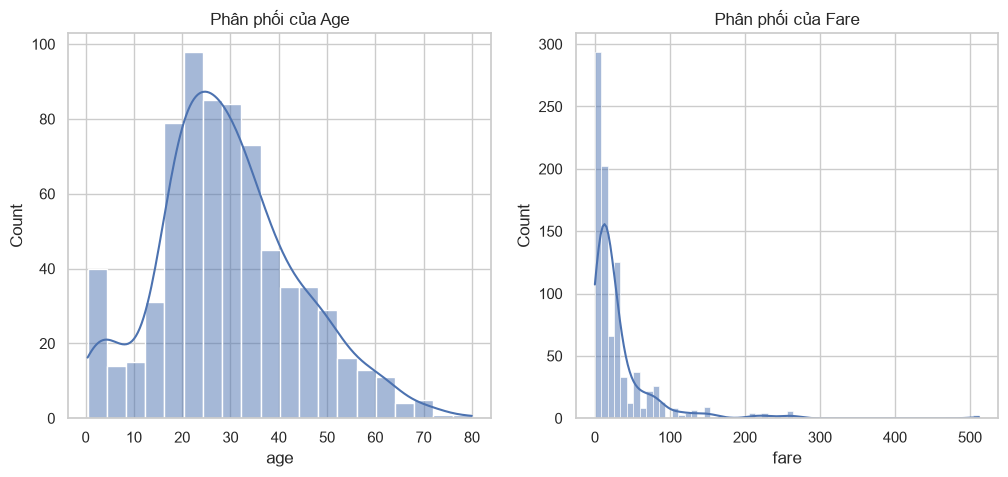

In [7]:
# TODO 5a: Histogram age & fare
fig, ax = plt.subplots(1,2, figsize = (12,5))

sns.histplot(df['age'].dropna(), kde = True, ax = ax[0])
ax[0].set_title('Phân phối của Age')

sns.histplot(df['fare'], kde = True, ax = ax[1])
ax[1].set_title('Phân phối của Fare')
plt.show()

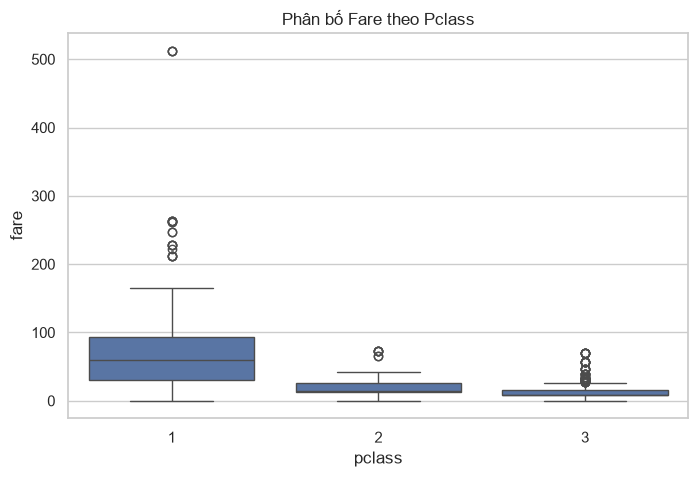

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize = (8,5))
sns.boxplot(data = df, x = 'pclass', y = 'fare')
plt.title('Phân bố Fare theo Pclass')
plt.show()

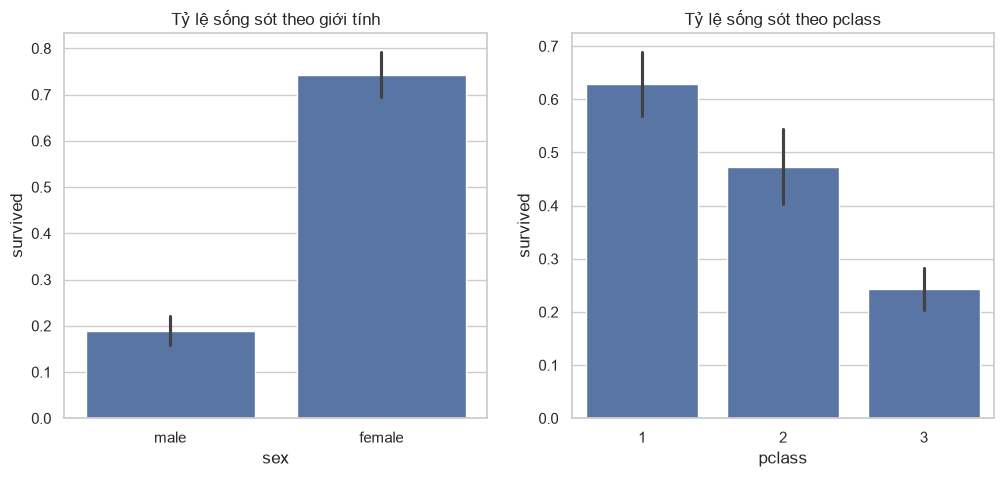

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
...
fig, ax = plt.subplots(1,2, figsize = (12, 5))

sns.barplot(data = df, x = 'sex', y = 'survived', ax = ax[0])
ax[0].set_title('Tỷ lệ sống sót theo giới tính')

sns.barplot(data = df, x = 'pclass', y = 'survived', ax = ax[1])
ax[1].set_title('Tỷ lệ sống sót theo pclass')
plt.show()

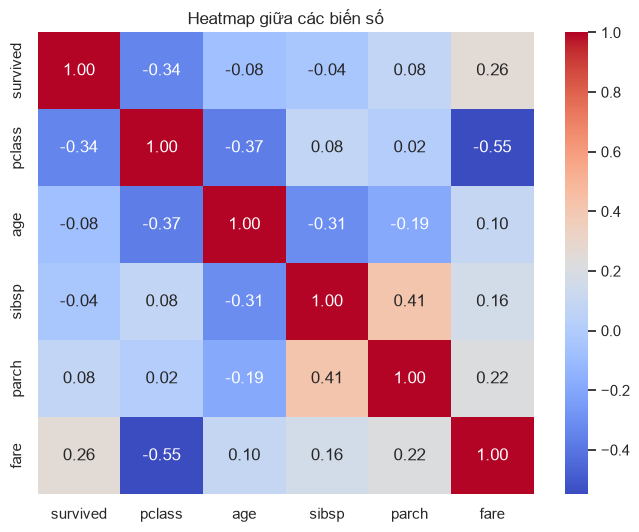

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize = (8,6))

numeric_df = df.select_dtypes(include = ['number'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Heatmap giữa các biến số')
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: phân phối của 'age' tập trung nhiều ở độ tuổi 20-30. Trong khi đó, 'fare' lệch phải rất mạnh, vì phần lớn hành khách chọn mức vé rẻ

- Boxplot: biểu đồ cho thấy khoang hạng 1 có phổ giá rất rộng và rất nhiều outlier ở mức > 200, trong khi vé hạng 2, 3 hội tụ ở vùng giá thấp và ít chênh lệch

- Bar survival: có thể thấy, nữ giới có tỉ lệ sống sót cao hơn rất nhiều so với nam giới (khoảng 74% so với 19%). Bên cạnh đó, cũng có thể thấy hành khác khoang hạng 1 sống sót nhiều nhất, giảm dần về hạng 3. 

- Heatmap: tương quan âm mạnh nhất (-0.55) thuộc về cặp 'pclass' và 'fare', phản ánh việc hạng vé càng nhỏ thì giá vé càng đắt

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns = ['survived'])
y = df['survived']

# X_tmp, X_test, y_tmp, y_test = train_test_split(...)
# X_train, X_val, y_train, y_val = train_test_split(...)
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size = 0.5, stratify = y_tmp, random_state = 42)

# print("Train/Val/Test:", ...)
# in tỷ lệ survived từng tập
print(f"Train: {X_train.shape} | Tỉ lệ survived: {y_train.mean():.2f}")
print(f"Val: {X_val.shape} | Tỉ lệ survived: {y_val.mean():.2f}")
print(f"Test: {X_test.shape} | Tỉ lệ survived: {y_test.mean():.2f}")

Train: (623, 7) | Tỉ lệ survived: 0.38
Val: (134, 7) | Tỉ lệ survived: 0.39
Test: (134, 7) | Tỉ lệ survived: 0.38


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    # ("imputer", ...),
    ("imputer", SimpleImputer(strategy = 'median')),
    # ("scaler",  ...),
    ("scaler", RobustScaler()),
])
pipe_cat = Pipeline([
    # ("imputer", ...),
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    # ("onehot",  ...),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)),
])

preprocess = ColumnTransformer([
    # ("num", pipe_so,  num_cols),
    ("num", pipe_so,  num_cols),
    # ("cat", pipe_cat, cat_cols),
    ("cat", pipe_cat, cat_cols),
    # ("ord", "passthrough", ord_cols),
    ("ord", "passthrough", ord_cols),
])

# preprocess.fit(X_train)               # fit CHỈ trên train
preprocess.fit(X_train)

# X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
# print(X_train_t.shape, list(preprocess.get_feature_names_out()))
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print("Shape sau biến đổi:", X_train_t.shape)
print("Danh sách Features:", list(preprocess.get_feature_names_out()))

Shape sau biến đổi: (623, 10)
Danh sách Features: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

*(viết tại đây...)*

Việc gọi hàm 'fit()' chỉ trên train giúp tránh leakage là vì nó giúp mô hình chỉ học các tham số từ đúng tập dữ liệu train, không dính phải dữ liệu từ tập validation và test

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print(df['survived'].value_counts(normalize = True))

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Biến 'survived' có bị mất cân bằng, tỉ lệ hành khách không sống sót chiếm khoảng 61.62% so với nhóm sống sót là khoảng 38.38%
2. Nếu chỉ nhìn vào Accuracy, ta có thể bị đánh lừa trong trường hợp dữ liệu bị mất cân bằng nghiêm trọng, ví dụ như khi 90% hành khách tử vong, nếu mô hình đoán mọi hành khách đều tử vọng thì đã bỏ sót đi toàn bộ những người sống sót
3. Với bài toán Titanic, ta nên ưu tiên F1-score vì dữ liệu có sự chênh lệch giữa 2 lớp, F1-score sẽ giúp cân bằng giữa precision và recall, việc dùng Accuracy có thể bị thiên vị nhẹ bởi nhóm tử vong vì nhóm này đông hơn.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng tương quan mạnh nhất với khả năng sống sót là 'pclass' và 'sex', dựa trên biểu đồ barplot, có thể thấy nữ giới có tỉ lệ sống rất cao, lên tới 74%, trong khi nam giới là 19%, còn hành khách vé hạng 1 có tỉ lệ sống sót lên đến 63%, trong khi vé hạng 2, 3 lần lượt là 48% và 24%
2. Cột 'deck' là dữ liệu bị thiếu nhiều nhất (chiếm khoảng 77%) nên đã bị loại bỏ hoàn toàn để tránh làm nhiễu model. Cột 'age' cũng thiếu nhiều, tầm 20% nhưng đã được thêm vào bằng Median
3. Biến mục tiêu 'survived' có bị mất cân bằng, cụ thể là bị lệch 61.62% tử vong và 38.38% sống sót, sự chênh lệch này ảnh hưởng tới việc chọn metric ở chỗ là ta cần xem xét F1-score thay vì tin vào Accuracy có thể bị thiên vị nhẹ
4. Đặc trưng cần scaling là 'fare' vì biến này chứa nhiều outlier cũng như phủ rất rộng, cụ thể là ta sử dụng RobustScaler cho nó để ép về cùng 1 thang đo với các biến khác. Các đặc trưng như 'sex' và 'embarked' là biến dạng chữ nên ta cần encoding bằng cách đưa qua OneHotEncoder.
5. Có thể thấy, dữ liệu cho thấy sự phân hóa giàu nghèo và có vẻ như nguyên tắc cứu hộ nghiêng về phụ nữ nhiều hơn, cũng như những người trong khoang hạng nhất sẽ có tỉ lệ sống sót cao.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [14]:
# (tùy chọn) code cho phần Bonus
...

Ellipsis

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
